In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import norm
from scipy import stats
import warnings
from sklearn.pipeline import Pipeline, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sklearn.linear_model import Ridge, Lasso, RidgeCV, LassoCV, LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import PolynomialFeatures
import warnings
warnings.filterwarnings('ignore')

### Load the dataset 

In [62]:
train_file_path = "input/house-prices-advanced-regression-techniques/train.csv"
train_df = pd.read_csv(train_file_path)

## Nettoyage des valeurs aberrantes (Outliers)

--- TOP 10 CORRÉLATIONS ---
['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd']


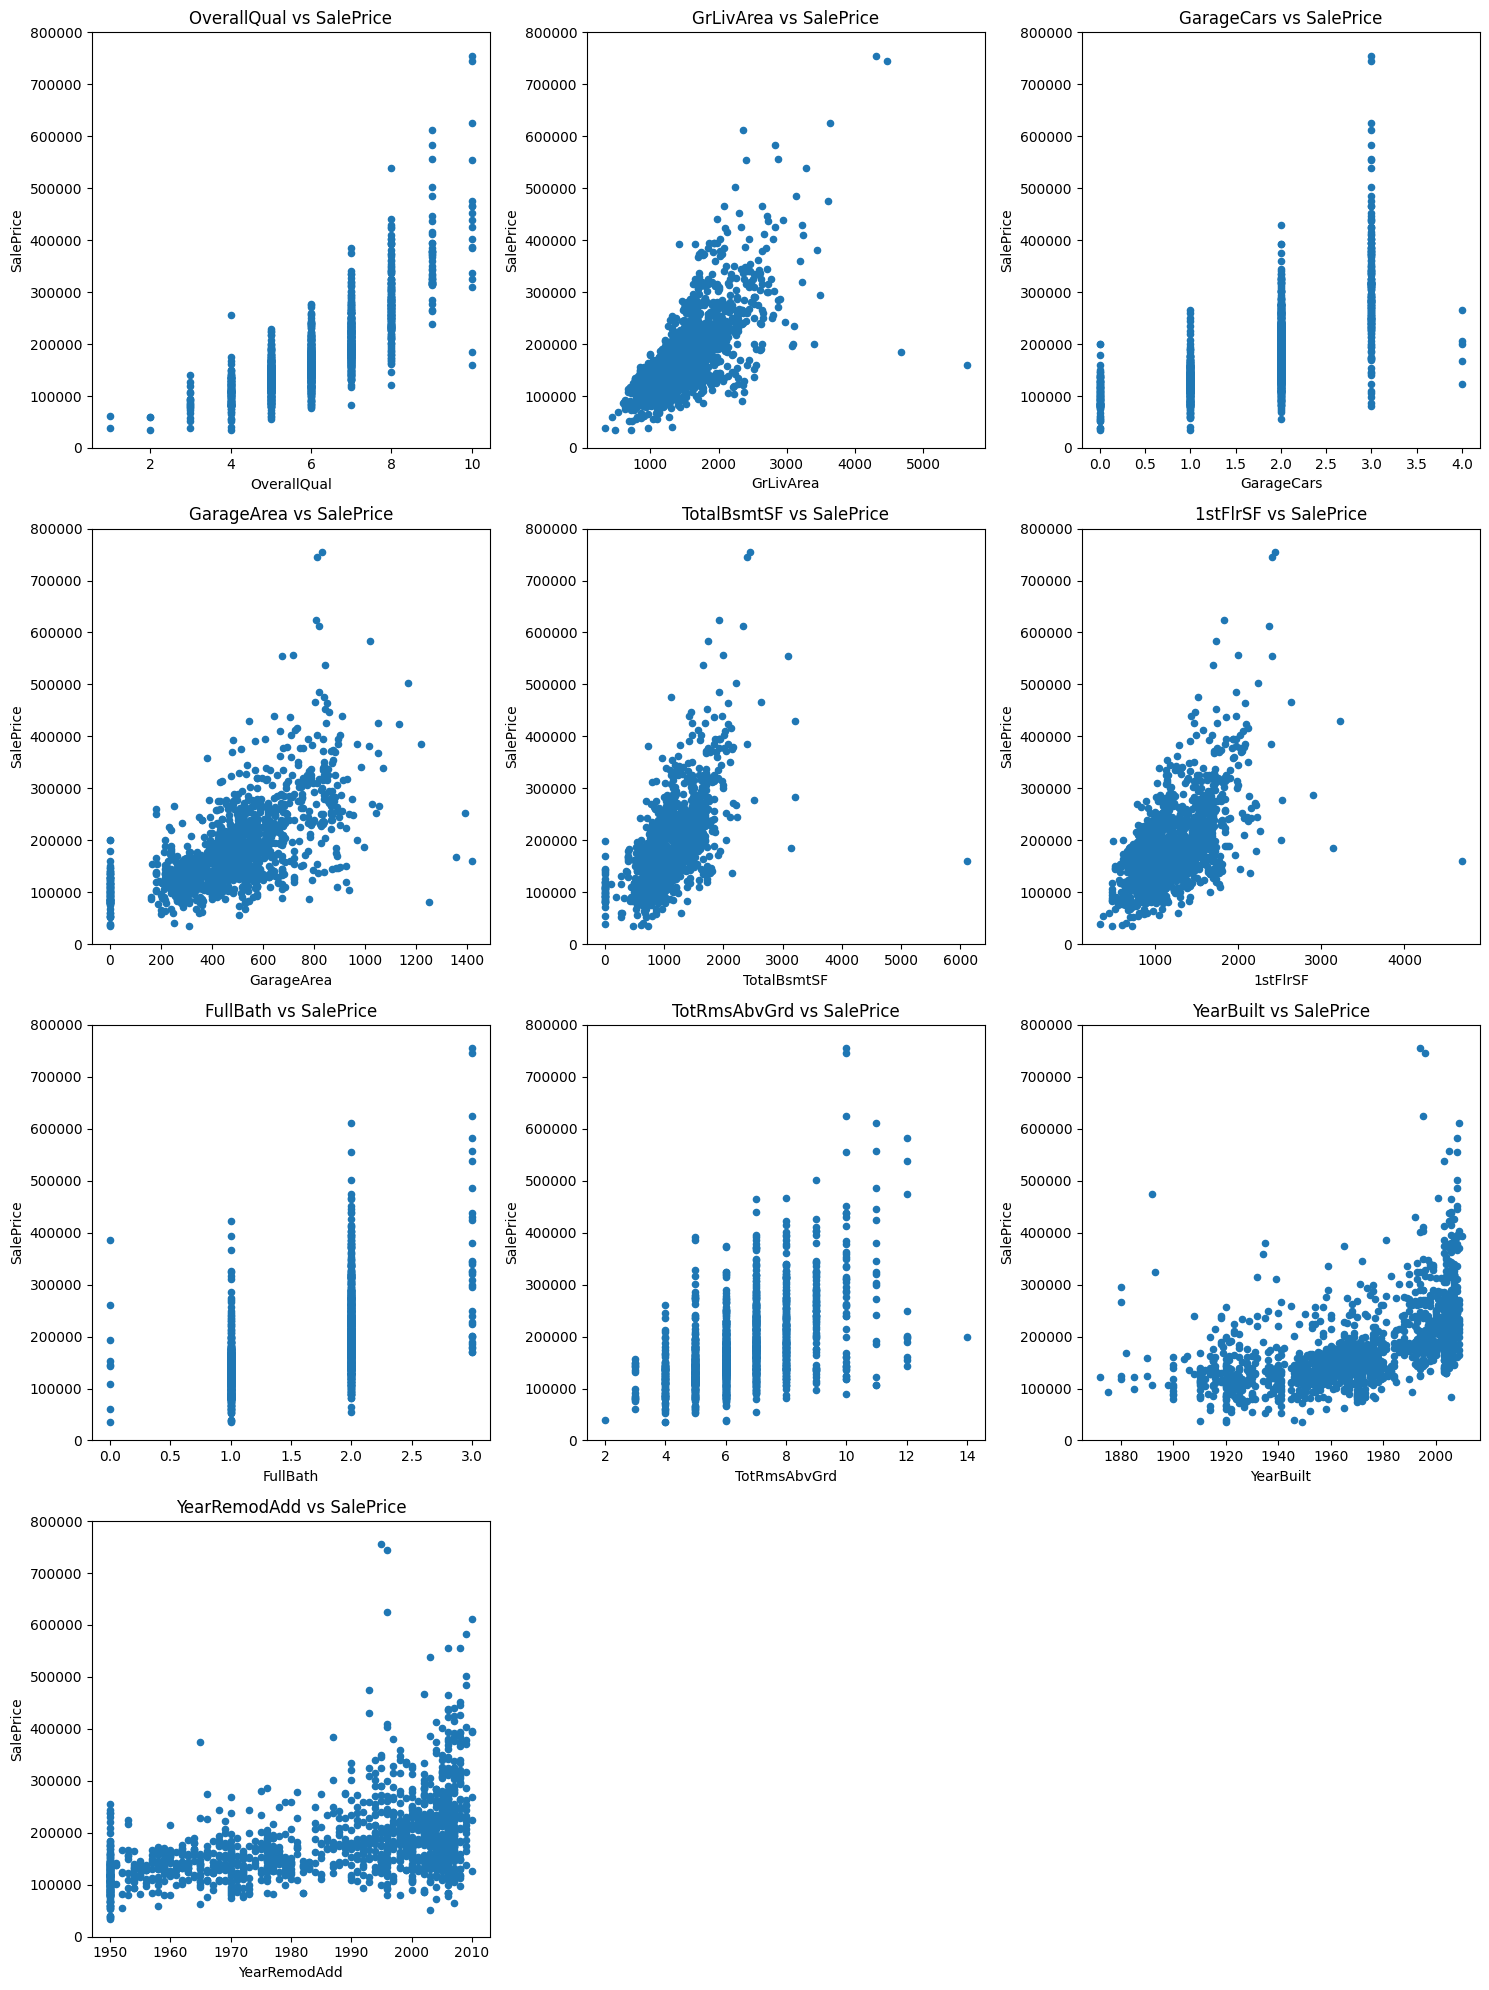

In [63]:
# 1. Identifier les 10 variables les plus corrélées au prix
print("--- TOP 10 CORRÉLATIONS ---")
corr = train_df.select_dtypes(include=['float64', 'int64']).corr()
top_10_cols = corr['SalePrice'].sort_values(ascending=False).head(11).index
top_10_cols = top_10_cols.drop('SalePrice')
print(top_10_cols.tolist())

num_cols = top_10_cols.tolist()

# Create subplots
fig, axes = plt.subplots(nrows=len(num_cols)//3 + 1, ncols=3, figsize=(15, 5*(len(num_cols)//3 + 1)))
axes = axes.flatten()

for i, var in enumerate(num_cols):
    data = pd.concat([train_df['SalePrice'], train_df[var]], axis=1)
    data.plot.scatter(x=var, y='SalePrice', ylim=(0,800000), ax=axes[i])
    axes[i].set_title(f'{var} vs SalePrice')

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## Pipeline 

In [65]:
# Préparation des données pour Feature Selection
X = train_df.drop(['SalePrice', 'Id'], axis=1)
y = train_df['SalePrice']
y_log = np.log1p(y)

# Imputer les valeurs manquantes AVANT la feature selection
numeric_features_full = X.select_dtypes(include=['int64', 'float64']).columns
imputer_num = SimpleImputer(strategy='median')
X_numeric_imputed = imputer_num.fit_transform(X[numeric_features_full])

# Sélectionner les meilleures features numériques
selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(X_numeric_imputed, y_log)

# Trier par score
feature_scores = pd.DataFrame({
    'feature': numeric_features_full,
    'score': selector.scores_
}).sort_values('score', ascending=False)

print("=== TOP 15 FEATURES (NUMÉRIQUES) ===")
print(feature_scores.head(15))

# Garder seulement les top 20 features numériques
top_numeric_features = feature_scores.head(20)['feature'].tolist()
print(f"\nGardées {len(top_numeric_features)} features numériques")

# Toutes les features catégorielles
categorical_features_selected = X.select_dtypes(include=['object']).columns.tolist()
print(f"Gardées {len(categorical_features_selected)} features catégorielles")

=== TOP 15 FEATURES (NUMÉRIQUES) ===
         feature        score
3    OverallQual  2646.543184
15     GrLivArea  1462.179302
25    GarageCars  1155.653238
26    GarageArea   960.841399
5      YearBuilt   940.734927
11   TotalBsmtSF   869.617037
18      FullBath   742.058604
12      1stFlrSF   732.534049
6   YearRemodAdd   699.974412
24   GarageYrBlt   530.672701
22  TotRmsAbvGrd   502.503512
23    Fireplaces   387.866407
7     MasVnrArea   256.528165
8     BsmtFinSF1   221.139189
1    LotFrontage   175.122234

Gardées 20 features numériques
Gardées 43 features catégorielles


In [66]:
# Utiliser les features sélectionnées
numeric_features = top_numeric_features
categorical_features = categorical_features_selected

print(f"\n=== PIPELINE ===")
print(f"Pipeline utilisant {len(numeric_features)} features numériques + {len(categorical_features)} features catégorielles")


=== PIPELINE ===
Pipeline utilisant 20 features numériques + 43 features catégorielles


In [67]:
# A. Pipeline pour les variables numériques
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Remplace NaN par la médiane
    ('scaler', RobustScaler())                     # Mise à l'échelle robuste aux outliers
])

# B. Pipeline pour les variables catégorielles
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')), # Remplace NaN par "None"
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) # Transforme en chiffres
])

# C. Assemblage du processeur final
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

## Feature Selection et Feature Engineering

In [68]:
# Cette cellule a été consolidée dans la cellule précédente - Feature Selection est déjà faite
pass

## Entraînement du Modèle (Baseline)

In [69]:
# Séparation Train/Test (partagée pour tous les modèles)
print("=== PRÉPARATION DES DONNÉES ===")
X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)
print(f"Train : {X_train.shape[0]} | Test : {X_test.shape[0]}")

# Split pour early stopping (validation interne)
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
print(f"Train : {X_tr.shape[0]} | Validation : {X_val.shape[0]}")

=== PRÉPARATION DES DONNÉES ===
Train : 1109 | Test : 278
Train : 887 | Validation : 222


#### Ridge

In [70]:
# 1. Création du Pipeline Ridge initial - BASELINE
ridge_model = Ridge(alpha=1.0)
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', ridge_model)
])

# 2. Entraînement baseline
ridge_pipeline.fit(X_train, y_train)

# 3. Évaluation baseline
y_pred_ridge_baseline = ridge_pipeline.predict(X_test)
rmse_ridge_baseline = np.sqrt(mean_squared_error(y_test, y_pred_ridge_baseline))

print(f"Résultat du modèle Ridge avant optimisation : {rmse_ridge_baseline:.5f}")

# 4. Définition de la grille de paramètres pour Ridge
param_grid_ridge = {
    'model__alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
}

# 5. Configurer la recherche
grid_search_ridge = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=param_grid_ridge,
    scoring='neg_root_mean_squared_error',
    cv=3,
    n_jobs=-1,
    verbose=1
)

# 6. Lancer la recherche
print("Recherche des meilleurs paramètres pour Ridge...")
grid_search_ridge.fit(X_train, y_train)

# 7. Résultats
print(f"\nMeilleurs paramètres Ridge trouvés : {grid_search_ridge.best_params_}")
best_score_ridge = -grid_search_ridge.best_score_
print(f"Meilleur score CV (RMSE) : {best_score_ridge:.5f}")

# 8. Test final sur le jeu de test
best_ridge_pipeline = grid_search_ridge.best_estimator_
y_pred_ridge = best_ridge_pipeline.predict(X_test)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print(f"Score final sur Test (Optimisé) : {rmse_ridge:.5f}")

Résultat du modèle Ridge avant optimisation : 0.11255
Recherche des meilleurs paramètres pour Ridge...
Fitting 3 folds for each of 6 candidates, totalling 18 fits

Meilleurs paramètres Ridge trouvés : {'model__alpha': 10.0}
Meilleur score CV (RMSE) : 0.11998
Score final sur Test (Optimisé) : 0.11057

Meilleurs paramètres Ridge trouvés : {'model__alpha': 10.0}
Meilleur score CV (RMSE) : 0.11998
Score final sur Test (Optimisé) : 0.11057


#### XGCBoost

In [71]:
# 1. Définition du modèle XGBoost - BASELINE (sans early stopping pour simplicité)
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    n_jobs=-1,
    random_state=42
)

# 2. Création du Pipeline XGBoost
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb_model)
])

# 3. Entraînement baseline
xgb_pipeline.fit(X_train, y_train)

# 4. Évaluation baseline
y_pred_xgb_baseline = xgb_pipeline.predict(X_test)
rmse_xgb_baseline = np.sqrt(mean_squared_error(y_test, y_pred_xgb_baseline))

print(f"Résultat du modèle XGBoost avant optimisation : {rmse_xgb_baseline:.5f}")

Résultat du modèle XGBoost avant optimisation : 0.12153


In [72]:
# 1. Définir la grille des paramètres à tester
param_grid = {
    'model__n_estimators': [1000, 1500],
    'model__max_depth': [3, 5],
    'model__learning_rate': [0.01, 0.05],
    'model__subsample': [0.7]
}

# 2. Configurer la recherche
grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=3,
    n_jobs=-1,
    verbose=1
)

# 3. Lancer la recherche
print("Recherche des meilleurs paramètres pour XGBoost...")
grid_search.fit(X_train, y_train)

# 4. Résultats
print(f"\nMeilleurs paramètres XGBoost trouvés : {grid_search.best_params_}")
best_score_xgb = -grid_search.best_score_
print(f"Meilleur score CV (RMSE) : {best_score_xgb:.5f}")

# 5. Test final sur le jeu de test
best_xgb_pipeline = grid_search.best_estimator_
y_pred_best = best_xgb_pipeline.predict(X_test)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))

print(f"Score final sur Test (Optimisé) : {rmse_best:.5f}")

Recherche des meilleurs paramètres pour XGBoost...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Meilleurs paramètres XGBoost trouvés : {'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 1500, 'model__subsample': 0.7}
Meilleur score CV (RMSE) : 0.12522
Score final sur Test (Optimisé) : 0.10875

Meilleurs paramètres XGBoost trouvés : {'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 1500, 'model__subsample': 0.7}
Meilleur score CV (RMSE) : 0.12522
Score final sur Test (Optimisé) : 0.10875


#### LightGBM

In [73]:
# 1. Création du Pipeline LightGBM initial - BASELINE
lgbm_model = LGBMRegressor(n_estimators=500, learning_rate=0.05, num_leaves=6, random_state=42, verbose=-1)
lgbm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', lgbm_model)
])

# 2. Entraînement baseline
lgbm_pipeline.fit(X_train, y_train)

# 3. Évaluation baseline
y_pred_lgbm_baseline = lgbm_pipeline.predict(X_test)
rmse_lgbm_baseline = np.sqrt(mean_squared_error(y_test, y_pred_lgbm_baseline))

print(f"Résultat du modèle LightGBM avant optimisation : {rmse_lgbm_baseline:.5f}")

# 4. Définition de la grille de paramètres pour LightGBM
param_grid_lgbm = {
    'model__n_estimators': [300, 500],
    'model__max_depth': [3, 5],
    'model__num_leaves': [4, 6],
    'model__learning_rate': [0.01, 0.05]
}

# 5. Configurer la recherche
grid_search_lgbm = GridSearchCV(
    estimator=lgbm_pipeline,
    param_grid=param_grid_lgbm,
    scoring='neg_root_mean_squared_error',
    cv=3,
    n_jobs=-1,
    verbose=1
)

# 6. Lancer la recherche
print("Recherche des meilleurs paramètres pour LightGBM...")
grid_search_lgbm.fit(X_train, y_train)

# 7. Résultats
print(f"\nMeilleurs paramètres LightGBM trouvés : {grid_search_lgbm.best_params_}")
best_score_lgbm = -grid_search_lgbm.best_score_
print(f"Meilleur score CV (RMSE) : {best_score_lgbm:.5f}")

# 8. Test final sur le jeu de test
best_lgbm_pipeline = grid_search_lgbm.best_estimator_
y_pred_lgbm = best_lgbm_pipeline.predict(X_test)
rmse_lgbm = np.sqrt(mean_squared_error(y_test, y_pred_lgbm))

print(f"Score final sur Test (Optimisé) : {rmse_lgbm:.5f}")

Résultat du modèle LightGBM avant optimisation : 0.11685
Recherche des meilleurs paramètres pour LightGBM...
Fitting 3 folds for each of 16 candidates, totalling 48 fits

Meilleurs paramètres LightGBM trouvés : {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 300, 'model__num_leaves': 6}
Meilleur score CV (RMSE) : 0.12873
Score final sur Test (Optimisé) : 0.11426

Meilleurs paramètres LightGBM trouvés : {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 300, 'model__num_leaves': 6}
Meilleur score CV (RMSE) : 0.12873
Score final sur Test (Optimisé) : 0.11426


#### Lasso 

#### RandomForest

In [74]:
# 1. Création du Pipeline RandomForest initial - BASELINE
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', rf_model)
])

# 2. Entraînement baseline
rf_pipeline.fit(X_train, y_train)

# 3. Évaluation baseline
y_pred_rf_baseline = rf_pipeline.predict(X_test)
rmse_rf_baseline = np.sqrt(mean_squared_error(y_test, y_pred_rf_baseline))

print(f"Résultat du modèle RandomForest avant optimisation : {rmse_rf_baseline:.5f}")

# 4. Définition de la grille de paramètres pour RandomForest
param_grid_rf = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, 15, 20],
    'model__min_samples_split': [2, 5],
}

# 5. Configurer la recherche
grid_search_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf,
    scoring='neg_root_mean_squared_error',
    cv=3,
    n_jobs=-1,
    verbose=1
)

# 6. Lancer la recherche
print("Recherche des meilleurs paramètres pour RandomForest...")
grid_search_rf.fit(X_train, y_train)

# 7. Résultats
print(f"\nMeilleurs paramètres RandomForest trouvés : {grid_search_rf.best_params_}")
best_score_rf = -grid_search_rf.best_score_
print(f"Meilleur score CV (RMSE) : {best_score_rf:.5f}")

# 8. Test final sur le jeu de test
best_rf_pipeline = grid_search_rf.best_estimator_
y_pred_rf = best_rf_pipeline.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f"Score final sur Test (Optimisé) : {rmse_rf:.5f}")

Résultat du modèle RandomForest avant optimisation : 0.12945
Recherche des meilleurs paramètres pour RandomForest...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Meilleurs paramètres RandomForest trouvés : {'model__max_depth': 15, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Meilleur score CV (RMSE) : 0.14169
Score final sur Test (Optimisé) : 0.12939

Meilleurs paramètres RandomForest trouvés : {'model__max_depth': 15, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Meilleur score CV (RMSE) : 0.14169
Score final sur Test (Optimisé) : 0.12939


#### GradientBoosting

In [75]:
# 1. Création du Pipeline GradientBoosting initial - BASELINE
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
gb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', gb_model)
])

# 2. Entraînement baseline
gb_pipeline.fit(X_train, y_train)

# 3. Évaluation baseline
y_pred_gb_baseline = gb_pipeline.predict(X_test)
rmse_gb_baseline = np.sqrt(mean_squared_error(y_test, y_pred_gb_baseline))

print(f"Résultat du modèle GradientBoosting avant optimisation : {rmse_gb_baseline:.5f}")

# 4. Définition de la grille de paramètres pour GradientBoosting
param_grid_gb = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.01, 0.1],
    'model__max_depth': [3, 5],
}

# 5. Configurer la recherche
grid_search_gb = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=param_grid_gb,
    scoring='neg_root_mean_squared_error',
    cv=3,
    n_jobs=-1,
    verbose=1
)

# 6. Lancer la recherche
print("Recherche des meilleurs paramètres pour GradientBoosting...")
grid_search_gb.fit(X_train, y_train)

# 7. Résultats
print(f"\nMeilleurs paramètres GradientBoosting trouvés : {grid_search_gb.best_params_}")
best_score_gb = -grid_search_gb.best_score_
print(f"Meilleur score CV (RMSE) : {best_score_gb:.5f}")

# 8. Test final sur le jeu de test
best_gb_pipeline = grid_search_gb.best_estimator_
y_pred_gb = best_gb_pipeline.predict(X_test)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))

print(f"Score final sur Test (Optimisé) : {rmse_gb:.5f}")

Résultat du modèle GradientBoosting avant optimisation : 0.11873
Recherche des meilleurs paramètres pour GradientBoosting...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Meilleurs paramètres GradientBoosting trouvés : {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200}
Meilleur score CV (RMSE) : 0.13009
Score final sur Test (Optimisé) : 0.11556

Meilleurs paramètres GradientBoosting trouvés : {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200}
Meilleur score CV (RMSE) : 0.13009
Score final sur Test (Optimisé) : 0.11556


In [76]:
# 1. Création du Pipeline Lasso initial - BASELINE
lasso_model = Lasso(alpha=0.1, max_iter=5000, random_state=42)
lasso_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', lasso_model)
])

# 2. Entraînement baseline
lasso_pipeline.fit(X_train, y_train)

# 3. Évaluation baseline
y_pred_lasso_baseline = lasso_pipeline.predict(X_test)
rmse_lasso_baseline = np.sqrt(mean_squared_error(y_test, y_pred_lasso_baseline))

print(f"Résultat du modèle Lasso avant optimisation : {rmse_lasso_baseline:.5f}")

# 4. Définition de la grille de paramètres pour Lasso
param_grid_lasso = {
    'model__alpha': [0.001, 0.01, 0.1, 1.0, 10.0],
}

# 5. Configurer la recherche
grid_search_lasso = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid=param_grid_lasso,
    scoring='neg_root_mean_squared_error',
    cv=3,
    n_jobs=-1,
    verbose=1
)

# 6. Lancer la recherche
print("Recherche des meilleurs paramètres pour Lasso...")
grid_search_lasso.fit(X_train, y_train)

# 7. Résultats
print(f"\nMeilleurs paramètres Lasso trouvés : {grid_search_lasso.best_params_}")
best_score_lasso = -grid_search_lasso.best_score_
print(f"Meilleur score CV (RMSE) : {best_score_lasso:.5f}")

# 8. Test final sur le jeu de test
best_lasso_pipeline = grid_search_lasso.best_estimator_
y_pred_lasso = best_lasso_pipeline.predict(X_test)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

print(f"Score final sur Test (Optimisé) : {rmse_lasso:.5f}")

Résultat du modèle Lasso avant optimisation : 0.23283
Recherche des meilleurs paramètres pour Lasso...
Fitting 3 folds for each of 5 candidates, totalling 15 fits

Meilleurs paramètres Lasso trouvés : {'model__alpha': 0.001}
Meilleur score CV (RMSE) : 0.11925
Score final sur Test (Optimisé) : 0.10976

Meilleurs paramètres Lasso trouvés : {'model__alpha': 0.001}
Meilleur score CV (RMSE) : 0.11925
Score final sur Test (Optimisé) : 0.10976


#### Mélange 

## Visualisations et Analyse Diagnostique

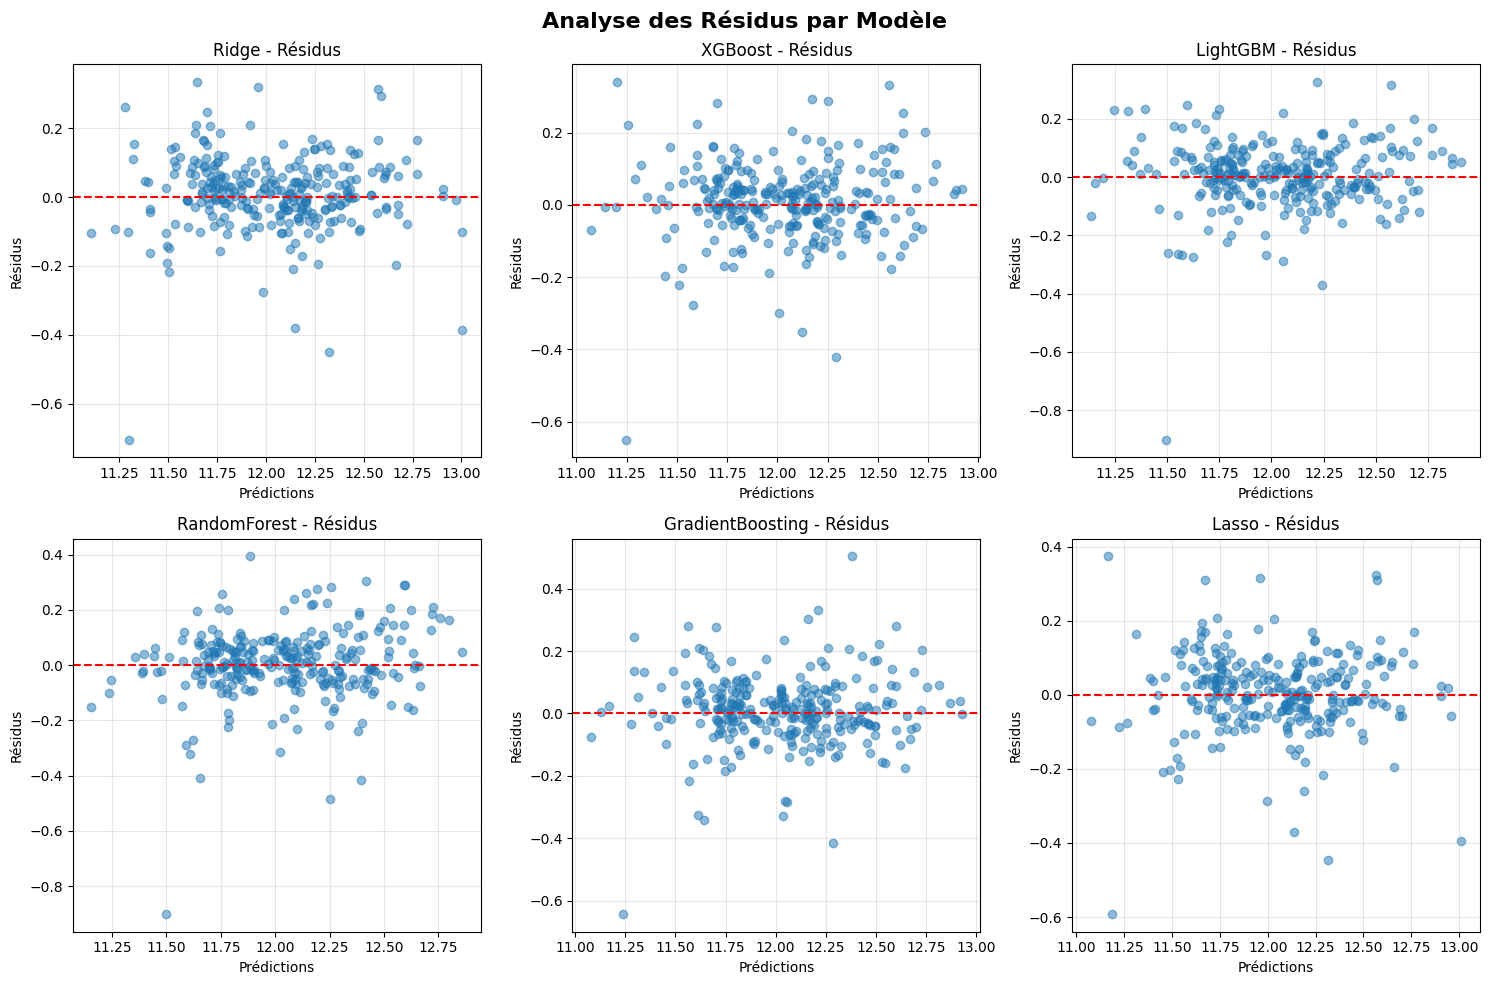


=== FEATURE IMPORTANCE (Top 10) ===
              feature  importance
0    num__OverallQual    0.521729
1      num__GrLivArea    0.122434
5    num__TotalBsmtSF    0.046367
3     num__GarageArea    0.038887
13    num__BsmtFinSF1    0.031043
4      num__YearBuilt    0.027384
8   num__YearRemodAdd    0.016005
7       num__1stFlrSF    0.014750
2     num__GarageCars    0.014702
18       num__LotArea    0.013816


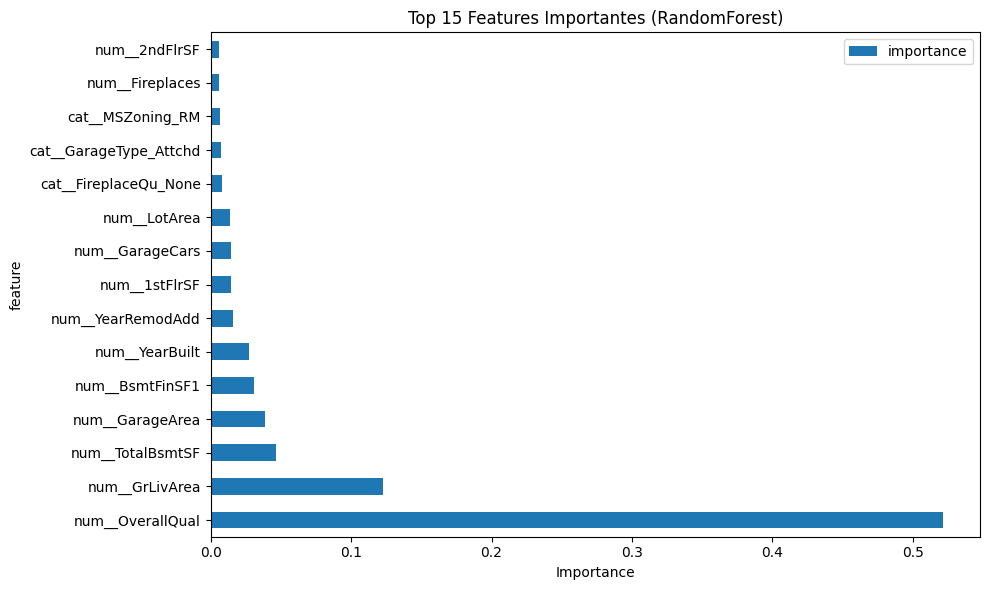

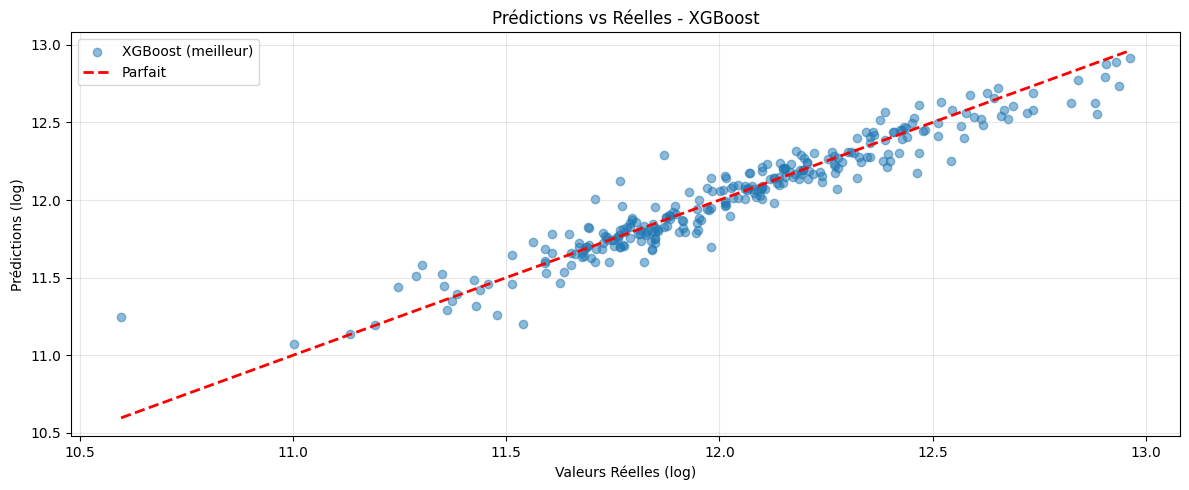

In [77]:
# 1. Graphique de comparaison des résidus
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Analyse des Résidus par Modèle', fontsize=16, fontweight='bold')

models_data = [
    (y_pred_ridge, 'Ridge', axes[0, 0]),
    (y_pred_best, 'XGBoost', axes[0, 1]),
    (y_pred_lgbm, 'LightGBM', axes[0, 2]),
    (y_pred_rf, 'RandomForest', axes[1, 0]),
    (y_pred_gb, 'GradientBoosting', axes[1, 1]),
    (y_pred_lasso, 'Lasso', axes[1, 2])
]

for pred, name, ax in models_data:
    residuals = y_test - pred
    ax.scatter(pred, residuals, alpha=0.5)
    ax.axhline(y=0, color='r', linestyle='--')
    ax.set_xlabel('Prédictions')
    ax.set_ylabel('Résidus')
    ax.set_title(f'{name} - Résidus')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 2. Feature Importance pour RandomForest
print("\n=== FEATURE IMPORTANCE (Top 10) ===")
feature_importance_rf = best_rf_pipeline.named_steps['model'].feature_importances_
X_test_transformed = best_rf_pipeline.named_steps['preprocessor'].transform(X_test)

# Créer un DataFrame d'importance
feature_names = (
    best_rf_pipeline.named_steps['preprocessor']
    .get_feature_names_out()
)
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance_rf
}).sort_values('importance', ascending=False)

print(importance_df.head(10))

# Visualiser
fig, ax = plt.subplots(figsize=(10, 6))
importance_df.head(15).plot(x='feature', y='importance', kind='barh', ax=ax)
ax.set_title('Top 15 Features Importantes (RandomForest)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

# 3. Distribution des prédictions vs réelles
fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(y_test, y_pred_best, alpha=0.5, label='XGBoost (meilleur)')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Parfait')
ax.set_xlabel('Valeurs Réelles (log)')
ax.set_ylabel('Prédictions (log)')
ax.set_title('Prédictions vs Réelles - XGBoost')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [78]:
# ========== STACKING AVANCÉ (Meilleur que Blending) ==========
print("\n" + "="*70)
print("CONSTRUCTION DU MODÈLE DE STACKING")
print("="*70)

# 1. Générer les prédictions de validation croisée (sans fuite de données!)
print("Génération des prédictions de stacking (validation croisée)...")

pred_ridge_meta = cross_val_predict(best_ridge_pipeline, X_train, y_train, cv=5)
pred_xgb_meta = cross_val_predict(best_xgb_pipeline, X_train, y_train, cv=5)
pred_lgbm_meta = cross_val_predict(best_lgbm_pipeline, X_train, y_train, cv=5)
pred_lasso_meta = cross_val_predict(best_lasso_pipeline, X_train, y_train, cv=5)
pred_rf_meta = cross_val_predict(best_rf_pipeline, X_train, y_train, cv=5)
pred_gb_meta = cross_val_predict(best_gb_pipeline, X_train, y_train, cv=5)

# 2. Créer la matrice de features meta-modèle
X_meta_train = np.column_stack([
    pred_ridge_meta, pred_xgb_meta, pred_lgbm_meta,
    pred_lasso_meta, pred_rf_meta, pred_gb_meta
])

print(f"Matrice de stacking (train) : {X_meta_train.shape}")

# 3. Entraîner le meta-modèle avec Ridge (régularisé pour éviter l'overfitting)
meta_model = Ridge(alpha=1.0)
meta_model.fit(X_meta_train, y_train)

# Obtenir les poids
weights = meta_model.coef_
weights_normalized = weights / weights.sum()

print(f"\nPoids optimaux trouvés (Stacking) :")
print(f"  Ridge        : {weights_normalized[0]:.4f}")
print(f"  XGBoost      : {weights_normalized[1]:.4f}")
print(f"  LightGBM     : {weights_normalized[2]:.4f}")
print(f"  Lasso        : {weights_normalized[3]:.4f}")
print(f"  RandomForest : {weights_normalized[4]:.4f}")
print(f"  GradBoosting : {weights_normalized[5]:.4f}")

# 4. Générer les prédictions sur le jeu de TEST
print("\nGénération des prédictions finales...")
pred_ridge_test = best_ridge_pipeline.predict(X_test)
pred_xgb_test = best_xgb_pipeline.predict(X_test)
pred_lgbm_test = best_lgbm_pipeline.predict(X_test)
pred_lasso_test = best_lasso_pipeline.predict(X_test)
pred_rf_test = best_rf_pipeline.predict(X_test)
pred_gb_test = best_gb_pipeline.predict(X_test)

# Assembler la matrice de test
X_meta_test = np.column_stack([
    pred_ridge_test, pred_xgb_test, pred_lgbm_test,
    pred_lasso_test, pred_rf_test, pred_gb_test
])

# 5. Appliquer le meta-modèle
final_pred_stacking = meta_model.predict(X_meta_test)
rmse_stacking = np.sqrt(mean_squared_error(y_test, final_pred_stacking))

# Alternative simple : moyenne pondérée
final_pred_blend = (
    weights_normalized[0] * pred_ridge_test + 
    weights_normalized[1] * pred_xgb_test + 
    weights_normalized[2] * pred_lgbm_test + 
    weights_normalized[3] * pred_lasso_test +
    weights_normalized[4] * pred_rf_test +
    weights_normalized[5] * pred_gb_test
)

rmse_blend = np.sqrt(mean_squared_error(y_test, final_pred_blend))

# 6. Affichage final complet
print(f"\n" + "="*70)
print("RÉSUMÉ FINAL DES PERFORMANCES (6 Modèles + Ensemble)")
print("="*70)
print(f"Ridge           (optimisé)  : {rmse_ridge:.5f}")
print(f"XGBoost         (optimisé)  : {rmse_best:.5f}")
print(f"LightGBM        (optimisé)  : {rmse_lgbm:.5f}")
print(f"Lasso           (optimisé)  : {rmse_lasso:.5f}")
print(f"RandomForest    (optimisé)  : {rmse_rf:.5f}")
print(f"GradientBoosting(optimisé)  : {rmse_gb:.5f}")
print("-" * 70)
print(f"Blending (moyenne pondérée) : {rmse_blend:.5f}")
print(f"Stacking (meta-modèle Ridge): {rmse_stacking:.5f}")
print("="*70)

best_score_final = min(rmse_ridge, rmse_best, rmse_lgbm, rmse_lasso, rmse_rf, rmse_gb, rmse_blend, rmse_stacking)
best_model_name = [
    ('Ridge', rmse_ridge),
    ('XGBoost', rmse_best),
    ('LightGBM', rmse_lgbm),
    ('Lasso', rmse_lasso),
    ('RandomForest', rmse_rf),
    ('GradientBoosting', rmse_gb),
    ('Blending', rmse_blend),
    ('Stacking', rmse_stacking)
]
best_model_name = max(best_model_name, key=lambda x: -x[1])

print(f"\n🏆 Meilleur modèle : {best_model_name[0]} avec RMSE = {best_model_name[1]:.5f}")
print("="*70)


CONSTRUCTION DU MODÈLE DE STACKING
Génération des prédictions de stacking (validation croisée)...
Matrice de stacking (train) : (1109, 6)

Poids optimaux trouvés (Stacking) :
  Ridge        : 0.2795
  XGBoost      : 0.2873
  LightGBM     : 0.0770
  Lasso        : 0.3278
  RandomForest : -0.0284
  GradBoosting : 0.0569

Génération des prédictions finales...

RÉSUMÉ FINAL DES PERFORMANCES (6 Modèles + Ensemble)
Ridge           (optimisé)  : 0.11057
XGBoost         (optimisé)  : 0.10875
LightGBM        (optimisé)  : 0.11426
Lasso           (optimisé)  : 0.10976
RandomForest    (optimisé)  : 0.12939
GradientBoosting(optimisé)  : 0.11556
----------------------------------------------------------------------
Blending (moyenne pondérée) : 0.10487
Stacking (meta-modèle Ridge): 0.10483

🏆 Meilleur modèle : Stacking avec RMSE = 0.10483
Matrice de stacking (train) : (1109, 6)

Poids optimaux trouvés (Stacking) :
  Ridge        : 0.2795
  XGBoost      : 0.2873
  LightGBM     : 0.0770
  Lasso     

## Métriques Additionnelles et Résumé Final


TABLEAU COMPLET DES MÉTRIQUES
           Model     RMSE      MAE       R²
        Stacking 0.104829 0.073233 0.921917
        Blending 0.104871 0.073103 0.921853
         XGBoost 0.108752 0.076030 0.915962
           Lasso 0.109760 0.077448 0.914398
           Ridge 0.110567 0.076442 0.913135
        LightGBM 0.114261 0.077720 0.907233
GradientBoosting 0.115564 0.079866 0.905105
    RandomForest 0.129387 0.087821 0.881046


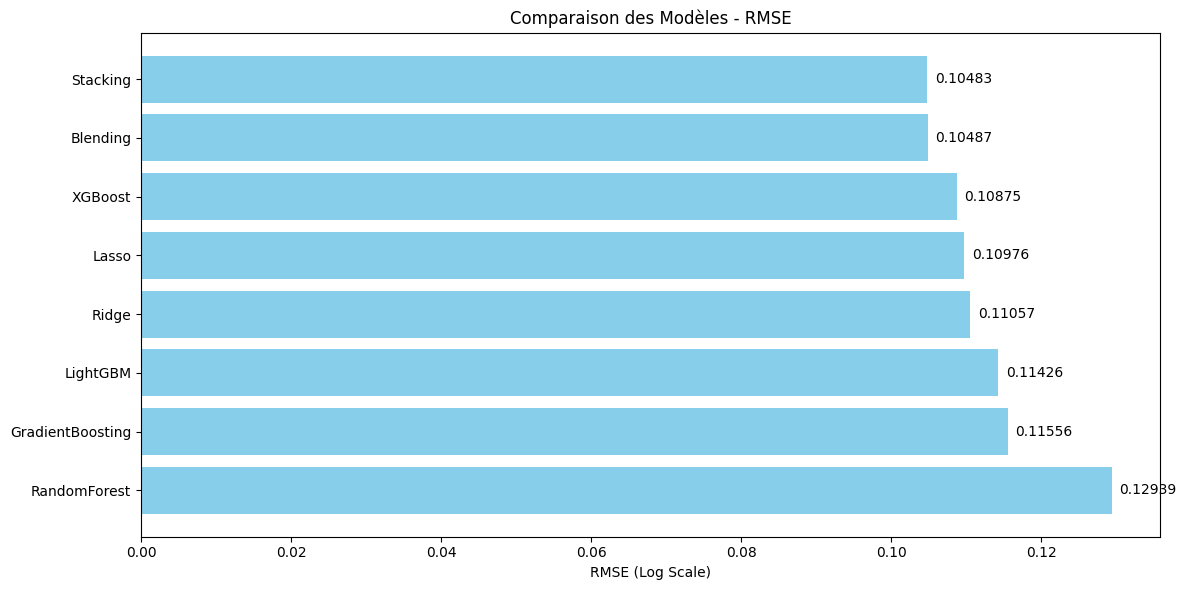


✅ Notebook amélioré complet ! Toutes les optimisations sont en place.


In [79]:
# Calculer des métriques supplémentaires
def calculate_metrics(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'Model': model_name, 'RMSE': rmse, 'MAE': mae, 'R²': r2}

metrics_list = [
    calculate_metrics(y_test, y_pred_ridge, 'Ridge'),
    calculate_metrics(y_test, y_pred_best, 'XGBoost'),
    calculate_metrics(y_test, y_pred_lgbm, 'LightGBM'),
    calculate_metrics(y_test, y_pred_lasso, 'Lasso'),
    calculate_metrics(y_test, y_pred_rf, 'RandomForest'),
    calculate_metrics(y_test, y_pred_gb, 'GradientBoosting'),
    calculate_metrics(y_test, final_pred_blend, 'Blending'),
    calculate_metrics(y_test, final_pred_stacking, 'Stacking'),
]

metrics_df = pd.DataFrame(metrics_list).sort_values('RMSE')
print("\n" + "="*70)
print("TABLEAU COMPLET DES MÉTRIQUES")
print("="*70)
print(metrics_df.to_string(index=False))
print("="*70)

# Visualiser les résultats
fig, ax = plt.subplots(figsize=(12, 6))
metrics_df_sorted = metrics_df.sort_values('RMSE')
ax.barh(metrics_df_sorted['Model'], metrics_df_sorted['RMSE'], color='skyblue')
ax.set_xlabel('RMSE (Log Scale)')
ax.set_title('Comparaison des Modèles - RMSE')
ax.invert_yaxis()
for i, v in enumerate(metrics_df_sorted['RMSE']):
    ax.text(v + 0.001, i, f'{v:.5f}', va='center')
plt.tight_layout()
plt.show()

print("\n✅ Notebook amélioré complet ! Toutes les optimisations sont en place.")

In [ ]:
# 1. Charger les données de test (celles sans le prix)
test_df = pd.read_csv('input/house-prices-advanced-regression-techniques/test.csv')

# Sauvegarder les IDs pour le fichier final
test_ids = test_df['Id']

# 2. Attention : Le pipeline attend les mêmes colonnes que l'entraînement
# On doit s'assurer que test_df a la même structure (sauf SalePrice bien sûr)
# Normalement, votre 'preprocessor' gère ça, mais il faut parfois gérer des catégories inconnues
# (C'est géré par handle_unknown='ignore' dans votre OneHotEncoder, donc tout va bien !)

# 3. Générer les prédictions avec le meilleur modèle (ici on utilise le stacking)
# Préparer X pour la prédiction (retirer Id)
X_test_final = test_df.drop(['Id'], axis=1)

# Générer les prédictions de tous les modèles sur test_df
pred_ridge_final = best_ridge_pipeline.predict(X_test_final)
pred_xgb_final = best_xgb_pipeline.predict(X_test_final)
pred_lgbm_final = best_lgbm_pipeline.predict(X_test_final)
pred_lasso_final = best_lasso_pipeline.predict(X_test_final)
pred_rf_final = best_rf_pipeline.predict(X_test_final)
pred_gb_final = best_gb_pipeline.predict(X_test_final)

# Assembler la matrice pour le meta-modèle
X_meta_final = np.column_stack([
    pred_ridge_final, pred_xgb_final, pred_lgbm_final,
    pred_lasso_final, pred_rf_final, pred_gb_final
])

# Appliquer le meta-modèle de stacking
final_predictions_log = meta_model.predict(X_meta_final)

# Convertir de log à prix réel
final_predictions = np.expm1(final_predictions_log)

# 4. Créer le fichier de soumission
submission = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': final_predictions
})



# Sauvegarde
submission.to_csv('submission.csv', index=False)
print("\n✅ Fichier 'submission.csv' généré avec succès !")

✅ Tout est bon ! Le fichier fait bien 1459 lignes.

✅ Fichier 'submission.csv' généré avec succès !
